In [30]:
import numpy as np
import pandas as pd
import kagglehub
import os
path=kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset')
print(os.listdir(path))
fake_df=pd.read_csv(os.path.join(path,"Fake.csv"))
true_df=pd.read_csv(os.path.join(path,"True.csv"))

['Fake.csv', 'True.csv']


In [31]:
fake_df.info()
true_df.info()
print(fake_df.isna().sum())
print(true_df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    23481 non-null  str  
 1   text     23481 non-null  str  
 2   subject  23481 non-null  str  
 3   date     23481 non-null  str  
dtypes: str(4)
memory usage: 733.9 KB
<class 'pandas.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    21417 non-null  str  
 1   text     21417 non-null  str  
 2   subject  21417 non-null  str  
 3   date     21417 non-null  str  
dtypes: str(4)
memory usage: 669.4 KB
title      0
text       0
subject    0
date       0
dtype: int64
title      0
text       0
subject    0
date       0
dtype: int64


In [45]:
#concat both into 1 df
fake_df['label'] = 1
true_df['label'] = 0
df=pd.concat([true_df,fake_df],ignore_index=True)
print(df.head())

print(df.info())
df = df.drop(columns=['date', 'subject'])
df['text'] = df['title'].fillna('') + ' ' + df['text'].fillna('')
df = df.drop(columns=['title'])

                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       0  
1  December 29, 2017       0  
2  December 31, 2017       0  
3  December 30, 2017       0  
4  December 29, 2017       0  
<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 

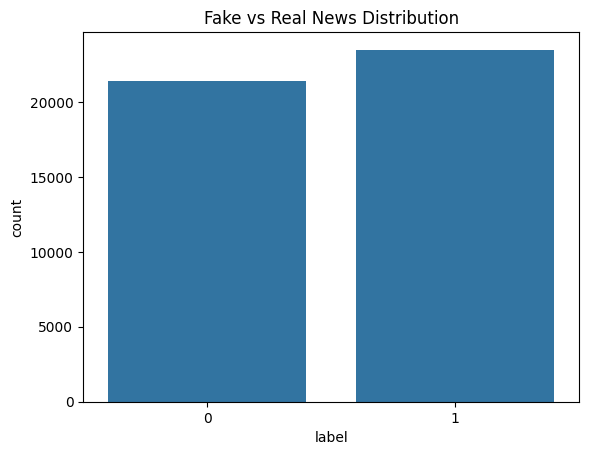

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=df["label"])
plt.title("Fake vs Real News Distribution")
plt.show()

In [52]:
#preprocess
from nltk.tokenize import word_tokenize
from sklearn.pipeline import Pipeline
from nltk.corpus import stopwords
from sklearn.compose import ColumnTransformer
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
import nltk

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')
y=df["label"]
x=df.drop(columns=["label"])
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, use_lemmatizer=True):
        self.use_lemmatizer = use_lemmatizer
        self.lemmatizer = WordNetLemmatizer()
        self.stopwords_set = set(stopwords.words('english'))
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.iloc[:, 0]  # assume single column
        processed_text = []
        for text in X:
            if not isinstance(text, str):
                text = str(text) if text is not None else ''
            tokens = word_tokenize(text.lower())
            tokens = [word for word in tokens if word not in self.stopwords_set]
            tokens = [self.lemmatizer.lemmatize(word) for word in tokens]
            processed_text.append(" ".join(tokens))
        return processed_text
vectorize=TfidfVectorizer()
preprocessor=ColumnTransformer(
    transformers=[
        ("word", Pipeline([("transform",TextPreprocessor()), ("vectorize", vectorize)]), x.columns)
    ]
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,shuffle=True)
model=LogisticRegression()
my_pipeline=Pipeline(
    steps=[
        ("preprocess",preprocessor),
        ("model",model)
    ]
)
my_pipeline.fit(x_train,y_train)

predictions=my_pipeline.predict(x_test)
print(accuracy_score(y_test,predictions))

0.9908685968819599
